In [1]:
import torch
from sklearn.model_selection import train_test_split

import GtoTmodel

In [2]:
from Circuits import Circuits
circuits=Circuits()
graph_data,text_data= circuits.data_lodder()


Loading dataset files...


In [3]:
len(graph_data)

3349

In [4]:
# Create a list of indexes for the original graph_data
original_indexes = list(range(len(graph_data)))

# Combine graph_data, text_data, and their indexes into a single list of tuples
combined_data_with_indexes = list(zip(graph_data, text_data, original_indexes))

# Shuffle and split the data into train and test sets
train_data, test_data = train_test_split(combined_data_with_indexes, test_size=0.1, random_state=42)

# Unzip the train and test data back into separate lists
train_graph_data, train_text_data, train_indexes = zip(*train_data)
test_graph_data, test_text_data, test_indexes = zip(*test_data)

# Convert back to lists
train_graph_data, train_text_data, train_indexes = list(train_graph_data), list(train_text_data), list(train_indexes)
test_graph_data, test_text_data, test_indexes = list(test_graph_data), list(test_text_data), list(test_indexes)

# Print the indexes of graph_data that went into test_graph_data
print(f"Train size: {len(train_graph_data)}, Test size: {len(test_graph_data)}")
print(f"Indexes of graph_data in test_graph_data: {test_indexes}")

Train size: 3014, Test size: 335
Indexes of graph_data in test_graph_data: [1830, 2628, 1552, 1236, 2975, 809, 2333, 2858, 1962, 631, 3185, 2655, 3301, 2114, 2840, 1018, 1615, 203, 2303, 309, 1075, 511, 3338, 621, 170, 134, 2474, 1677, 596, 1017, 3258, 2218, 1602, 807, 1947, 70, 1720, 2177, 1091, 1739, 485, 746, 2018, 1831, 322, 1517, 3335, 2543, 450, 314, 257, 2905, 289, 2672, 1135, 1108, 30, 1936, 387, 831, 2671, 51, 1702, 1572, 174, 1242, 944, 3107, 969, 734, 2315, 847, 2650, 439, 183, 2786, 764, 1621, 2560, 1419, 2592, 2867, 1891, 2943, 2159, 1999, 1536, 2579, 2788, 32, 2844, 787, 2501, 857, 1431, 1078, 997, 2684, 2940, 139, 486, 2225, 2366, 1510, 2216, 2316, 2213, 52, 2289, 461, 239, 1937, 17, 2206, 3231, 368, 1606, 2666, 3087, 1472, 1666, 2810, 2148, 2212, 325, 2254, 1422, 538, 864, 506, 2325, 410, 80, 194, 1225, 93, 1037, 1022, 3077, 859, 3166, 2241, 291, 196, 1253, 3015, 1362, 501, 3070, 759, 3329, 932, 2318, 2894, 594, 2884, 805, 1457, 2003, 2718, 1980, 1971, 897, 3189, 1717, 

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embed_dim = 32  # Embedding dimension
num_heads = 4  # Number of attention heads
num_layers = 4 # Number of transformer layers
dropout = 0.1  # Dropout rate
graph_input_dim = 310  # Number of colomns in the graph
text_vocab_size = 894  # Vocabulary size for text

model = GtoTmodel.GraphToTextTransformer(
    graph_input_dim, 
    text_vocab_size, 
    embed_dim, 
    num_heads, 
    num_layers, 
    dropout)

model = model.to(device)

/home/nithira/circuits_gen/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [6]:
graph_dataset = torch.cat(graph_data).to(device)
text_dataset = torch.cat(text_data,).to(device)
print(graph_dataset.shape,text_dataset.shape)

train_graph_dataset = torch.cat(train_graph_data).to(device)
train_text_dataset = torch.cat(train_text_data).to(device)
print(train_graph_dataset.shape,train_text_dataset.shape)

test_graph_dataset = torch.cat(test_graph_data).to(device)
test_text_dataset = torch.cat(test_text_data).to(device)
print(test_graph_dataset.shape,test_text_dataset.shape)

torch.Size([351461, 310]) torch.Size([351461])
torch.Size([318061, 310]) torch.Size([318061])
torch.Size([33400, 310]) torch.Size([33400])


### Taining

In [7]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

# Hyperparameters
learning_rate = 0.001
num_epochs = 75
batch_size = 64

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)  # Assuming 0 is the padding index
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Prepare data batches
train_graph_batches = [train_graph_data[i:i + batch_size] for i in range(0, len(train_graph_data), batch_size)]
train_text_batches = [train_text_data[i:i + batch_size] for i in range(0, len(train_text_data), batch_size)]

val_graph_batches = [test_graph_data[i:i + batch_size] for i in range(0, len(test_graph_data), batch_size)]
val_text_batches = [test_text_data[i:i + batch_size] for i in range(0, len(test_text_data), batch_size)]

print(f"Number of training batches: {len(train_graph_batches)}")
print(f"Number of validation batches: {len(val_graph_batches)}")

# Training and Validation Loop
for epoch in range(num_epochs):
    # ========== Training ==========
    model.train()
    train_loss = 0

    for graph_batch, text_batch in tqdm(zip(train_graph_batches, train_text_batches), total=len(train_graph_batches), desc=f"Epoch {epoch+1} [Training]"):
        # Move data to device
        text_batch = torch.nn.utils.rnn.pad_sequence(text_batch, batch_first=True).to(device)
        graph_batch = torch.nn.utils.rnn.pad_sequence(graph_batch, batch_first=True).to(device)

        # Prepare decoder inputs
        decoder_input = text_batch[:, :-1]
        decoder_target = text_batch[:, 1:]

        # Forward pass
        outputs = model(graph_batch, decoder_input)

        # Compute loss
        outputs = outputs.reshape(-1, outputs.size(-1))
        decoder_target = decoder_target.reshape(-1).long()
        loss = criterion(outputs, decoder_target)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_graph_batches)

    # ========== Validation ==========
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for graph_batch, text_batch in tqdm(zip(val_graph_batches, val_text_batches), total=len(val_graph_batches), desc=f"Epoch {epoch+1} [Validation]"):
            # Move data to device
            text_batch = torch.nn.utils.rnn.pad_sequence(text_batch, batch_first=True).to(device)
            graph_batch = torch.nn.utils.rnn.pad_sequence(graph_batch, batch_first=True).to(device)

            # Prepare decoder inputs
            decoder_input = text_batch[:, :-1]
            decoder_target = text_batch[:, 1:]

            # Forward pass
            outputs = model(graph_batch, decoder_input)

            # Compute loss
            outputs = outputs.reshape(-1, outputs.size(-1))
            decoder_target = decoder_target.reshape(-1).long()
            loss = criterion(outputs, decoder_target)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_graph_batches)

    print(f"Epoch {epoch+1}/{num_epochs} --> Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

print("Training complete.")


Number of training batches: 48
Number of validation batches: 6


Epoch 1 [Validation]: 100%|██████████| 6/6 [00:00<00:00, 65.95it/s]


Epoch 1/75 --> Train Loss: 5.2898, Val Loss: 3.9045


Epoch 2 [Validation]: 100%|██████████| 6/6 [00:00<00:00, 65.38it/s]


Epoch 2/75 --> Train Loss: 3.2197, Val Loss: 2.4686


...

Epoch 73/75 --> Train Loss: 1.1705, Val Loss: 1.1854


Epoch 74 [Validation]: 100%|██████████| 6/6 [00:00<00:00, 66.36it/s]


Epoch 74/75 --> Train Loss: 1.1696, Val Loss: 1.1841


Epoch 75 [Validation]: 100%|██████████| 6/6 [00:00<00:00, 66.41it/s]

Epoch 75/75 --> Train Loss: 1.1688, Val Loss: 1.1832
Training complete.


In [8]:
# Initialize test loss
test_loss = 0
# Prepare test data batches
test_graph_batches = [test_graph_data[i:i + batch_size] for i in range(0, len(test_graph_data), batch_size)]
test_text_batches = [test_text_data[i:i + batch_size] for i in range(0, len(test_text_data), batch_size)]


# Evaluation loop for test loss
model.eval()
with torch.no_grad():
    for graph_batch, text_batch in tqdm(zip(test_graph_batches, test_text_batches), total=len(test_graph_batches)):
        # Move data to device
        text_batch = torch.nn.utils.rnn.pad_sequence(text_batch, batch_first=True).to(device)
        graph_batch = torch.nn.utils.rnn.pad_sequence(graph_batch, batch_first=True).to(device)

        # Prepare input and target for the decoder
        decoder_input = text_batch[:, :-1]  # All except the last token
        decoder_target = text_batch[:, 1:]  # All except the first token

        # Forward pass
        outputs = model(graph_batch, decoder_input)

        # Compute loss
        outputs = outputs.reshape(-1, outputs.size(-1))  # Flatten for CrossEntropyLoss
        decoder_target = decoder_target.reshape(-1).long()  # Flatten target and cast to Long
        loss = criterion(outputs, decoder_target)

        test_loss += loss.item()

# Calculate average test loss
average_test_loss = test_loss / len(test_graph_batches)
print(f"Test Loss: {average_test_loss:.4f}")

100%|██████████| 6/6 [00:00<00:00, 65.64it/s]

Test Loss: 1.1832


In [9]:
# Define the file path to save the model and hyperparameters
save_path = "model_checkpoint.pth"

# Create a dictionary to store the model state and hyperparameters
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'embed_dim': embed_dim,
    'num_heads': num_heads,
    'num_layers': num_layers,
    'dropout': dropout,
    'learning_rate': learning_rate,
    'text_vocab_size': text_vocab_size,
    'graph_input_dim': graph_input_dim,
}

# Save the checkpoint
torch.save(checkpoint, save_path)
print(f"Model and hyperparameters saved to {save_path}")

Model and hyperparameters saved to model_checkpoint.pth


In [10]:
test_graph_data[1].shape

torch.Size([188, 310])

### Genereate Sequence

In [11]:
# # Load the saved model checkpoint
checkpoint_path = "model_checkpoint.pth"
checkpoint = torch.load(checkpoint_path)

# # Reinitialize the model with the saved hyperparameters
model = GtoTmodel.GraphToTextTransformer(
        graph_input_dim=checkpoint['graph_input_dim'],
        text_vocab_size=checkpoint['text_vocab_size'],
        embed_dim=checkpoint['embed_dim'],
        num_heads=checkpoint['num_heads'],
        num_layers=checkpoint['num_layers'],
        dropout=checkpoint['dropout']
    ).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Select a sample graph input
sample_graph = test_graph_data[0].unsqueeze(0).to(device)  # Add batch dimension
print(sample_graph)

# Generate a sequence
start_token =test_text_data[1] #torch.tensor([892], dtype=torch.long).to(device)  # Assuming 0 is the start token
# generated_sequence = [start_token.item()]
generated_sequence = list(start_token[:10]) # Start with the start token

for _ in range(5000):  # Generate up to 50 tokens
    input_sequence = torch.tensor(generated_sequence, dtype=torch.long).unsqueeze(0).to(device)
    output = model(sample_graph, input_sequence)
    next_token = torch.argmax(output[:, -1, :], dim=-1).item()  # Get the most probable next token
    generated_sequence.append(next_token)
    if next_token == 892:  # Assuming 892 is the end token
        break

# Convert indices back to components
generated_text = circuits.get_component_fromlist(generated_sequence)

print("Generated Sequence:", generated_text)
print(circuits.get_component_fromlist(start_token))

/home/nithira/circuits_gen/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [9., 9., 9.,  ..., 9., 9., 9.]]], device='cuda:0')
Generated Sequence: ['VDD', 'VSS', 'VIN1', 'VOUT1', 'VB1', 'VB2', 'VB3', 'VCONT1', 'VCONT2', 'VCONT3', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B', 'NM2', 'NM2_D', 'NM2_G', 'NM2_S', 'NM2_B', 'NM3', 'NM3_D', 'NM3_G', 'NM3_S', 'NM3_B', 'NM4', 'NM4_D', 'NM4_G', 'NM4_S', 'NM4_B', 'NM5', 'NM5_D', 'NM5_G', 'NM5_S', 'NM5_B', 'NM6', 'NM6_D', 'NM6_G', 'NM6_S', 'NM6_B', 'NM7', 'NM7_D', 'NM7_G', 'NM7_S', 'NM7_B', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'PM2', 'PM2_D', 'PM2_G', 'PM2_S', 'PM2_B', 'PM3', 'PM3_D', 'PM3_G', 'PM3_S', 'PM3_B', 'PM4', 'PM4_D', 'PM4_G', 'PM4_S', 'PM4_B', 'NM8', 'NM8_D', 'NM8_G', 'NM8_S', 'NM8_B', 'NM9', 'NM9_D', 'NM9_G', 'NM9_S', 'NM9_B', 'PM5', 'PM5_D', 'PM5_G', 'PM5_S', 'PM5_B', 'R1', 'R1_P', 'R

### Accuracy Checking

In [12]:
component_prediction = []

def evaluate_accuracy(model, test_graph_data, test_text_data, circuits, device, num_samples=100):
    """
    Evaluate the accuracy of the model by incrementally predicting the next component
    in the sequence.
    
    Args:
        model: The trained model
        test_graph_data: List of graph tensors
        test_text_data: List of text tensors (component sequences)
        circuits: Circuits object for component conversion
        device: Device to run evaluation on
        num_samples: Number of samples to evaluate (default: 100)
    
    Returns:
        Dictionary with accuracy metrics
    """
    model.eval()
    
    # Limit the number of samples for evaluation
    num_samples = min(num_samples, len(test_graph_data))
    
    total_predictions = 0
    correct_predictions = 0
    
    # Track accuracy at different sequence positions
    position_correct = {}
    position_total = {}
    
    for i in range(num_samples):
        graph = test_graph_data[i].unsqueeze(0).to(device)
        target_sequence = test_text_data[i].to('cpu').tolist()
        
        # Skip the end token if present for the evaluation
        if 892 in target_sequence:  # 892 is the end token
            end_position = target_sequence.index(892)
            if end_position > 0:  # Make sure there's at least one token before the end
                target_sequence = target_sequence[:end_position + 1]
            else:
                continue  # Skip sequences that are just the end token
        
        for j in range(1, len(target_sequence)):
            # Input sequence is everything up to the current position
            input_sequence = torch.tensor(target_sequence[:j], dtype=torch.long).unsqueeze(0).to(device)
            
            # Target is the next component
            target = target_sequence[j]
            
            # Generate prediction
            with torch.no_grad():
                output = model(graph, input_sequence)
                prediction = torch.argmax(output[:, -1, :], dim=-1).item()
            
            # Check if prediction is correct
            is_correct = (prediction == target)
            
            # Update counters
            total_predictions += 1
            if is_correct:
                correct_predictions += 1
            
            # Track position-specific accuracy
            pos = j
            if pos not in position_total:
                position_total[pos] = 0
                position_correct[pos] = 0
            
            position_total[pos] += 1
            if is_correct:
                position_correct[pos] += 1
    
    # Calculate overall accuracy
    overall_accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
    
    # Calculate position-specific accuracy
    position_accuracy = {pos: position_correct[pos] / position_total[pos] 
                        for pos in position_total.keys()}
    
    # Print detailed results
    print(f"Overall Accuracy: {overall_accuracy:.4f} ({correct_predictions}/{total_predictions})")
    print("\nAccuracy by Position:")
    for pos in sorted(position_accuracy.keys()):
        print(f"Position {pos}: {position_accuracy[pos]:.4f} ({position_correct[pos]}/{position_total[pos]})")
    
    return {
        "overall_accuracy": overall_accuracy,
        "position_accuracy": position_accuracy,
        "total_predictions": total_predictions,
        "correct_predictions": correct_predictions
    }


def evaluate_with_beam_search(model, test_graph_data, test_text_data, circuits, device, 
                             beam_width=3, max_length=50, num_samples=20):
    """
    Evaluate the model using beam search decoding to generate complete sequences.
    
    Args:
        model: The trained model
        test_graph_data: List of graph tensors
        test_text_data: List of text tensors (component sequences)
        circuits: Circuits object for component conversion
        device: Device to run evaluation on
        beam_width: Width of the beam for beam search
        max_length: Maximum sequence length to generate
        num_samples: Number of samples to evaluate
    
    Returns:
        Dictionary with evaluation metrics
    """
    model.eval()
    
    # Limit the number of samples
    num_samples = min(num_samples, len(test_graph_data))
    
    # Initialize metrics
    exact_match = 0
    bleu_scores = []
    component_precision = []
    component_recall = []
    
    end_token = 892  # Assuming 892 is the end token
    
    for i in range(num_samples):
        graph = test_graph_data[i].unsqueeze(0).to(device)
        target_sequence = test_text_data[i].to('cpu').tolist()
        
        # Clean target sequence - remove padding and stop at end token
        if end_token in target_sequence:
            target_sequence = target_sequence[:target_sequence.index(end_token) + 1]
        
        # Initial input is just the start token or the first token
        # For simplicity, we'll use the first token of the target sequence
        current_input = torch.tensor([target_sequence[0]], dtype=torch.long).unsqueeze(0).to(device)
        
        # Initialize beam
        beams = [(current_input, 0.0)]  # (sequence, score)
        
        # Beam search
        for _ in range(max_length):
            candidates = []
            
            for sequence, score in beams:
                # Check if sequence already has end token
                if sequence[0, -1].item() == end_token:
                    candidates.append((sequence, score))
                    continue
                
                # Generate predictions
                with torch.no_grad():
                    output = model(graph, sequence)
                    logits = output[0, -1]
                    probs = torch.nn.functional.softmax(logits, dim=-1)
                
                # Get top-k next tokens
                topk_probs, topk_indices = torch.topk(probs, beam_width)
                
                # Add new candidates
                for prob, idx in zip(topk_probs, topk_indices):
                    new_sequence = torch.cat([sequence, torch.tensor([[idx.item()]], device=device)], dim=1)
                    new_score = score - torch.log(prob).item()  # Negative log likelihood
                    candidates.append((new_sequence, new_score))
                    
                    # Stop if we've found the end token
                    if idx.item() == end_token:
                        break
            
            # Select top-k candidates
            candidates.sort(key=lambda x: x[1])
            beams = candidates[:beam_width]
            
            # Check if all beams end with the end token
            if all(beam[0][0, -1].item() == end_token for beam in beams):
                break
        
        # Best sequence is the first beam
        predicted_sequence = beams[0][0][0].cpu().tolist()
        
        # Convert to component names for better analysis
        predicted_components = circuits.get_component_fromlist(predicted_sequence)
        target_components = circuits.get_component_fromlist(target_sequence)

        component_prediction.append(predicted_components)

        # Check exact match (ignoring end token)
        is_exact_match = False
        if len(predicted_sequence) == len(target_sequence):
            if all(p == t for p, t in zip(predicted_sequence[:-1], target_sequence[:-1])):
                exact_match += 1
                is_exact_match = True
        
        # Calculate precision and recall of components
        predicted_set = set(predicted_components)
        target_set = set(target_components)
        
        if 'end' in predicted_set:
            predicted_set.remove('end')
        if 'end' in target_set:
            target_set.remove('end')
        
        common_components = predicted_set.intersection(target_set)
        precision = len(common_components) / len(predicted_set) if predicted_set else 0
        recall = len(common_components) / len(target_set) if target_set else 0
        
        component_precision.append(precision)
        component_recall.append(recall)
        
        # Print details for this sample
        print(f"\nSample {i+1}:")
        print(f"Target: {target_components}")
        print(f"Predicted: {predicted_components}")
        print(f"Exact Match: {is_exact_match}")
        print(f"Component Precision: {precision:.4f}, Recall: {recall:.4f}")
    
    # Calculate overall metrics
    avg_precision = sum(component_precision) / len(component_precision)
    avg_recall = sum(component_recall) / len(component_recall)
    avg_f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
    exact_match_rate = exact_match / num_samples
    
    print("\nOverall Metrics:")
    print(f"Exact Match Rate: {exact_match_rate:.4f} ({exact_match}/{num_samples})")
    print(f"Average Component Precision: {avg_precision:.4f}")
    print(f"Average Component Recall: {avg_recall:.4f}")
    print(f"Average F1 Score: {avg_f1:.4f}")
    
    return {
        "exact_match_rate": exact_match_rate,
        "avg_precision": avg_precision,
        "avg_recall": avg_recall,
        "avg_f1": avg_f1
    }

# Add this to the end of your train.py file to run the evaluation
if __name__ == "__main__":
    print("\n=== Evaluating Model Accuracy ===")
    print(len(test_graph_data))
    accuracy_metrics = evaluate_accuracy(model, test_graph_data, test_text_data, circuits, device, num_samples=100)
    
    
    print("\n=== Evaluating with Beam Search ===")
    beam_search_metrics = evaluate_with_beam_search(model, test_graph_data, test_text_data, circuits, device, 
                                                  beam_width=3, max_length=50, num_samples=100)


=== Evaluating Model Accuracy ===
335
Overall Accuracy: 0.9459 (9058/9576)

Accuracy by Position:
Position 1: 0.9800 (98/100)
Position 2: 0.7800 (78/100)
Position 3: 0.5900 (59/100)
Position 4: 0.8400 (84/100)
Position 5: 0.7700 (77/100)
Position 6: 0.7700 (77/100)
Position 7: 0.7400 (74/100)
Position 8: 0.8800 (88/100)
Position 9: 0.8800 (88/100)
Position 10: 0.9200 (92/100)
Position 11: 0.9800 (98/100)
Position 12: 0.9800 (98/100)
Position 13: 0.9700 (97/100)
Position 14: 0.9300 (93/100)
Position 15: 0.9394 (93/99)
Position 16: 0.9691 (94/97)
Position 17: 0.9485 (92/97)
Position 18: 0.9684 (92/95)
Position 19: 0.9892 (92/93)
Position 20: 0.9783 (90/92)
Position 21: 0.9780 (89/91)
Position 22: 0.9444 (85/90)
Position 23: 0.9091 (80/88)
Position 24: 0.9770 (85/87)
Position 25: 0.9767 (84/86)
Position 26: 0.9881 (83/84)
Position 27: 0.9524 (80/84)
Position 28: 0.9286 (78/84)
Position 29: 0.9762 (82/84)
Position 30: 0.9759 (81/83)
Position 31: 0.9639 (80/83)
Position 32: 0.9518 (79/83)


In [13]:
import pickle

print(component_prediction)

# Save the list variable to a file
with open("component_prediction.pkl", "wb") as f:
    pickle.dump(component_prediction, f)

# To load the list variable again from the file
with open("component_prediction.pkl", "rb") as f:
    component_prediction = pickle.load(f)


[['VDD', 'VSS', 'VIN1', 'VIN2', 'VOUT1', 'VB1', 'VB2', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'PM2', 'PM2_D', 'PM2_G', 'PM2_S', 'PM2_B', 'PM3', 'PM3_D', 'PM3_G', 'PM3_S', 'PM3_B', 'PM4', 'PM4_D', 'PM4_G', 'PM4_S', 'PM4_B', 'PM5', 'PM5_D', 'PM5_G', 'PM5_S', 'PM5_B', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B', 'NM2', 'NM2_D', 'NM2_G', 'NM2_S', 'NM2_B', 'NM3', 'NM3_D', 'NM3_G', 'NM3_S', 'NM3_B', 'NM4', 'NM4_D', 'NM4_G', 'NM4_S'], ['VDD', 'VSS', 'VIN1', 'VOUT1', 'VB1', 'VB2', 'VB3', 'VCONT1', 'VCONT2', 'VCONT3', 'VCONT4', 'VCONT5', 'VREF1', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'PM2', 'PM2_D', 'PM2_G', 'PM2_S', 'PM2_B', 'PM3', 'PM3_D', 'PM3_G', 'PM3_S', 'PM3_B', 'PM4', 'PM4_D', 'PM4_G', 'PM4_S', 'PM4_B', 'PM5', 'PM5_D', 'PM5_G', 'PM5_S', 'PM5_B', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B', 'NM2', 'NM2_D', 'NM2_G', 'NM2_S', 'NM2_B', 'NM3', 'NM3_D', 'NM3_G'], ['VDD', 'VSS', 'VIN1', 'VIN2', 'VOUT1', 'VB1', 'VB2', 'VB3', 'VB4', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'PM2', 'PM2_D', 

In [14]:
def evaluate_milestone_accuracy(model, test_graph_data, test_text_data, circuits, device, 
                               milestones=[20, 50, 100], num_samples=100):
    """
    Evaluate the accuracy of the model at specific component milestones.
    
    Args:
        model: The trained model
        test_graph_data: List of graph tensors
        test_text_data: List of text tensors (component sequences)
        circuits: Circuits object for component conversion
        device: Device to run evaluation on
        milestones: List of positions to evaluate accuracy at
        num_samples: Number of samples to evaluate
    
    Returns:
        Dictionary with accuracy metrics at each milestone
    """
    model.eval()
    
    # Limit the number of samples for evaluation
    num_samples = min(num_samples, len(test_graph_data))
    
    # Initialize counters for each milestone
    milestone_correct = {m: 0 for m in milestones}
    milestone_total = {m: 0 for m in milestones}
    
    # Track all predictions for overall accuracy
    total_predictions = 0
    correct_predictions = 0
    
    # Track position-specific accuracy
    position_correct = {}
    position_total = {}
    
    for i in range(num_samples):
        graph = test_graph_data[i].unsqueeze(0).to(device)
        target_sequence = test_text_data[i].to('cpu').tolist()
        
        # Skip the end token if present for the evaluation
        if 892 in target_sequence:  # 892 is the end token
            end_position = target_sequence.index(892)
            if end_position > 0:  # Make sure there's at least one token before the end
                target_sequence = target_sequence[:end_position + 1]
            else:
                continue  # Skip sequences that are just the end token
        
        # Skip sequences that are too short for evaluation
        if len(target_sequence) < 2:
            continue
        
        # Evaluate incrementally
        current_sequence = [target_sequence[0]]  # Start with the first component
        
        for j in range(1, len(target_sequence)):
            # Input sequence is everything up to the current position
            input_sequence = torch.tensor(current_sequence, dtype=torch.long).unsqueeze(0).to(device)
            
            # Target is the next component
            target = target_sequence[j]
            
            # Generate prediction
            with torch.no_grad():
                output = model(graph, input_sequence)
                prediction = torch.argmax(output[:, -1, :], dim=-1).item()
            
            # Check if prediction is correct
            is_correct = (prediction == target)
            
            # Update counters
            total_predictions += 1
            if is_correct:
                correct_predictions += 1
                current_sequence.append(target)  # Add the correct component
            else:
                current_sequence.append(prediction)  # Add the predicted component
            
            # Track position-specific accuracy
            pos = j
            if pos not in position_total:
                position_total[pos] = 0
                position_correct[pos] = 0
            
            position_total[pos] += 1
            if is_correct:
                position_correct[pos] += 1
            
            # Track milestone accuracy
            for milestone in milestones:
                if pos == milestone:
                    milestone_total[milestone] += 1
                    if is_correct:
                        milestone_correct[milestone] += 1
    
    # Calculate overall accuracy
    overall_accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
    
    # Calculate position-specific accuracy
    position_accuracy = {pos: position_correct[pos] / position_total[pos] 
                        for pos in position_total.keys()}
    
    # Calculate milestone accuracy
    milestone_accuracy = {m: milestone_correct[m] / milestone_total[m] 
                         if milestone_total[m] > 0 else 0 
                         for m in milestones}
    
    # Print detailed results
    print(f"Overall Accuracy: {overall_accuracy:.4f} ({correct_predictions}/{total_predictions})")
    
    print("\nAccuracy by Milestone:")
    for m in sorted(milestone_accuracy.keys()):
        if milestone_total[m] > 0:
            print(f"Component {m}: {milestone_accuracy[m]:.4f} ({milestone_correct[m]}/{milestone_total[m]})")
        else:
            print(f"Component {m}: No data (sequences too short)")
    
    print("\nAccuracy by Position (first 10):")
    for pos in sorted(position_accuracy.keys())[:10]:  # Show first 10 positions
        print(f"Position {pos}: {position_accuracy[pos]:.4f} ({position_correct[pos]}/{position_total[pos]})")
    
    return {
        "overall_accuracy": overall_accuracy,
        "position_accuracy": position_accuracy,
        "milestone_accuracy": milestone_accuracy
    }

def evaluate_sequence_accuracy(model, test_graph_data, test_text_data, circuits, device, num_samples=100):
    """
    Evaluate how well the model does at predicting entire sequences by computing accuracy
    up to different sequence lengths.
    
    This function:
    1. Starts with the first component
    2. Incrementally predicts the next component, adding it to the sequence
    3. Measures accuracy after 20, 50, and 100 components
    4. Also generates complete sequences and compares with targets
    
    Args:
        model: The trained model
        test_graph_data: List of graph tensors
        test_text_data: List of text tensors (component sequences)
        circuits: Circuits object for component conversion
        device: Device to run evaluation on
        num_samples: Number of samples to evaluate
    """
    model.eval()
    
    # Limit the number of samples for evaluation
    num_samples = min(num_samples, len(test_graph_data))
    
    # Milestone tracking
    milestones = [20, 50, 100]
    milestone_accuracies = {m: [] for m in milestones}
    
    # End token
    end_token = 892
    
    # Track completed sequences
    complete_sequences = 0
    total_sequences = 0
    
    for i in range(num_samples):
        graph = test_graph_data[i].unsqueeze(0).to(device)
        target_sequence = test_text_data[i].to('cpu').tolist()
        
        # Skip the end token if present for the evaluation
        if end_token in target_sequence:
            end_position = target_sequence.index(end_token)
            if end_position > 0:  # Make sure there's at least one token before the end
                target_sequence = target_sequence[:end_position + 1]
            else:
                continue  # Skip sequences that are just the end token
        
        # Skip sequences that are too short for any milestone
        if len(target_sequence) < min(milestones) + 1:
            continue
            
        total_sequences += 1
        
        # Start with the first token
        current_sequence = [target_sequence[0]]
        predicted_sequence = [target_sequence[0]]  # Start with the same first token
        
        # Generate the rest of the sequence
        max_len = max(len(target_sequence) + 10, 200)  # Allow some extra tokens
        
        for j in range(1, max_len):
            # Current input sequence
            input_sequence = torch.tensor(current_sequence, dtype=torch.long).unsqueeze(0).to(device)
            
            # Generate prediction
            with torch.no_grad():
                output = model(graph, input_sequence)
                prediction = torch.argmax(output[:, -1, :], dim=-1).item()
            
            # Add prediction to sequence
            predicted_sequence.append(prediction)
            current_sequence.append(prediction)
            
            # Check if we've reached the end token
            if prediction == end_token:
                break
                
            # Check milestones if we have enough tokens
            for m in milestones:
                if j == m:
                    # Calculate accuracy at this milestone
                    target_up_to_m = target_sequence[1:m+1]  # Skip the first token
                    predicted_up_to_m = predicted_sequence[1:m+1]  # Skip the first token
                    
                    correct = sum(1 for p, t in zip(predicted_up_to_m, target_up_to_m) if p == t)
                    accuracy = correct / m
                    milestone_accuracies[m].append(accuracy)
        
        # Check if we ended up with a complete sequence
        predicted_ended = predicted_sequence[-1] == end_token
        if predicted_ended:
            complete_sequences += 1
            
        # Print sequence details
        print(f"\nSample {i+1}:")
        print(f"Target length: {len(target_sequence)}")
        print(f"Predicted length: {len(predicted_sequence)}")
        print(f"Completed sequence: {predicted_ended}")
        
        # Calculate overall accuracy for this sequence
        min_len = min(len(target_sequence), len(predicted_sequence))
        correct = sum(1 for p, t in zip(predicted_sequence[:min_len], target_sequence[:min_len]) if p == t)
        accuracy = correct / min_len
        print(f"Sequence accuracy: {accuracy:.4f} ({correct}/{min_len})")
        
        # Print first few components
        print("Target start:", circuits.get_component_fromlist(target_sequence[:5]))
        print("Predicted start:", circuits.get_component_fromlist(predicted_sequence[:5]))
    
    # Calculate and print average milestone accuracies
    print("\nAverage Accuracy at Milestones:")
    for m in milestones:
        if milestone_accuracies[m]:
            avg_accuracy = sum(milestone_accuracies[m]) / len(milestone_accuracies[m])
            print(f"Component {m}: {avg_accuracy:.4f} (from {len(milestone_accuracies[m])} samples)")
        else:
            print(f"Component {m}: No data (sequences too short)")
    
    # Print completion statistics
    completion_rate = complete_sequences / total_sequences if total_sequences > 0 else 0
    print(f"\nSequence Completion Rate: {completion_rate:.4f} ({complete_sequences}/{total_sequences})")
    
    return {
        "milestone_accuracies": {m: sum(v) / len(v) if v else 0 for m, v in milestone_accuracies.items()},
        "completion_rate": completion_rate
    }

# Add this to your script to run both evaluations
if __name__ == "__main__":
    print("\n=== Evaluating Model at Component Milestones ===")
    milestone_metrics = evaluate_milestone_accuracy(model, test_graph_data, test_text_data, circuits, device, 
                                                  milestones=[20, 50, 100], num_samples=100)
    
    print("\n=== Evaluating Complete Sequence Generation ===")
    sequence_metrics = evaluate_sequence_accuracy(model, test_graph_data, test_text_data, circuits, device, 
                                                num_samples=20)


=== Evaluating Model at Component Milestones ===
Overall Accuracy: 0.0787 (754/9576)

Accuracy by Milestone:
Component 20: 0.1087 (10/92)
Component 50: 0.0260 (2/77)
Component 100: 0.0196 (1/51)

Accuracy by Position (first 10):
Position 1: 0.9800 (98/100)
Position 2: 0.7700 (77/100)
Position 3: 0.4400 (44/100)
Position 4: 0.4100 (41/100)
Position 5: 0.2900 (29/100)
Position 6: 0.2100 (21/100)
Position 7: 0.1200 (12/100)
Position 8: 0.1200 (12/100)
Position 9: 0.1100 (11/100)
Position 10: 0.1100 (11/100)

=== Evaluating Complete Sequence Generation ===

Sample 1:
Target length: 88
Predicted length: 98
Completed sequence: True
Sequence accuracy: 0.0568 (5/88)
Target start: ['VDD', 'VSS', 'VIN1', 'VIN2', 'VOUT1']
Predicted start: ['VDD', 'VSS', 'VIN1', 'VIN2', 'VOUT1']

Sample 2:
Target length: 188
Predicted length: 200
Completed sequence: False
Sequence accuracy: 0.0372 (7/188)
Target start: ['VDD', 'VSS', 'VIN1', 'VOUT1', 'VB1']
Predicted start: ['VDD', 'VSS', 'VIN1', 'VOUT1', 'VB1']


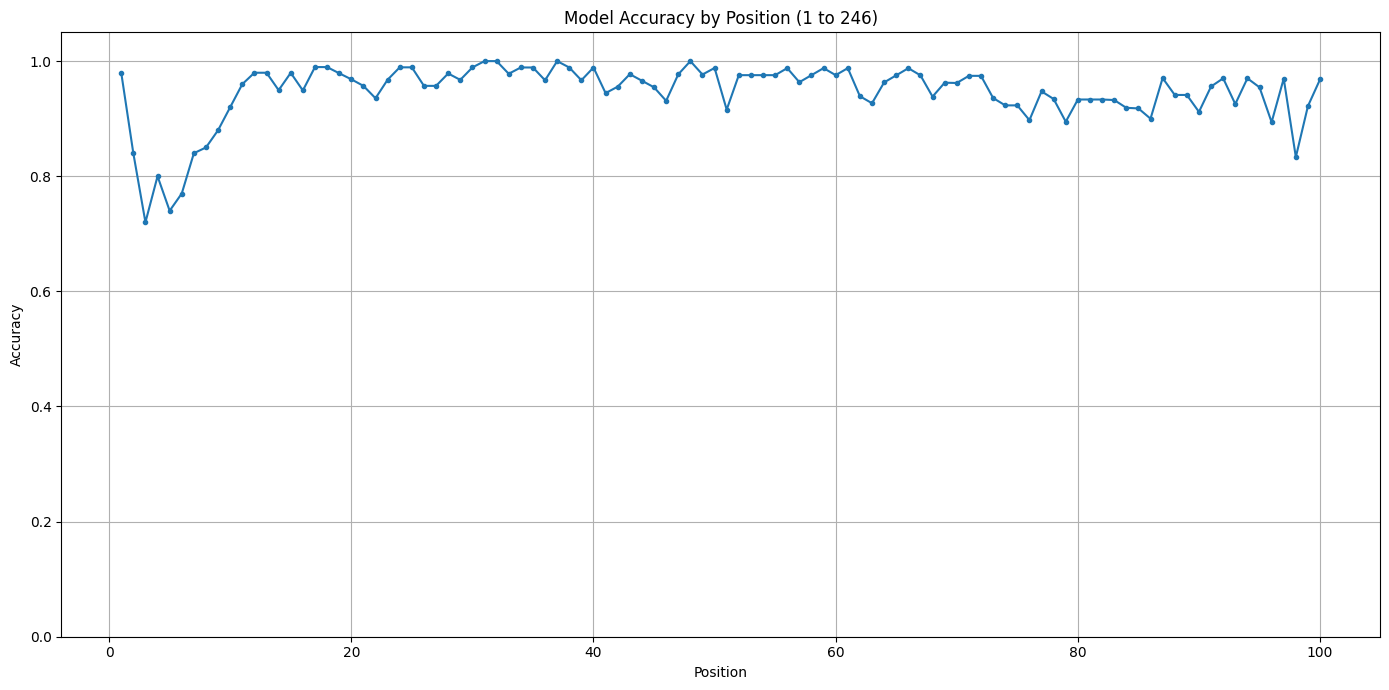

In [15]:
# Full accuracy data as a single string (already provided in the user's message)
import re

from matplotlib import pyplot as plt


full_data = """
Position 1: 0.9800 (98/100)
Position 2: 0.8400 (84/100)
Position 3: 0.7200 (72/100)
Position 4: 0.8000 (80/100)
Position 5: 0.7400 (74/100)
Position 6: 0.7700 (77/100)
Position 7: 0.8400 (84/100)
Position 8: 0.8500 (85/100)
Position 9: 0.8800 (88/100)
Position 10: 0.9200 (92/100)
Position 11: 0.9600 (96/100)
Position 12: 0.9798 (97/99)
Position 13: 0.9798 (97/99)
Position 14: 0.9495 (94/99)
Position 15: 0.9796 (96/98)
Position 16: 0.9490 (93/98)
Position 17: 0.9897 (96/97)
Position 18: 0.9896 (95/96)
Position 19: 0.9789 (93/95)
Position 20: 0.9684 (92/95)
Position 21: 0.9570 (89/93)
Position 22: 0.9355 (87/93)
Position 23: 0.9677 (90/93)
Position 24: 0.9892 (92/93)
Position 25: 0.9892 (92/93)
Position 26: 0.9570 (89/93)
Position 27: 0.9570 (89/93)
Position 28: 0.9785 (91/93)
Position 29: 0.9674 (89/92)
Position 30: 0.9890 (90/91)
Position 31: 1.0000 (91/91)
Position 32: 1.0000 (91/91)
Position 33: 0.9780 (89/91)
Position 34: 0.9890 (90/91)
Position 35: 0.9889 (89/90)
Position 36: 0.9667 (87/90)
Position 37: 1.0000 (90/90)
Position 38: 0.9889 (89/90)
Position 39: 0.9667 (87/90)
Position 40: 0.9889 (89/90)
Position 41: 0.9444 (85/90)
Position 42: 0.9556 (86/90)
Position 43: 0.9773 (86/88)
Position 44: 0.9659 (85/88)
Position 45: 0.9545 (84/88)
Position 46: 0.9310 (81/87)
Position 47: 0.9770 (85/87)
Position 48: 1.0000 (86/86)
Position 49: 0.9767 (84/86)
Position 50: 0.9881 (83/84)
Position 51: 0.9157 (76/83)
Position 52: 0.9756 (80/82)
Position 53: 0.9756 (80/82)
Position 54: 0.9756 (80/82)
Position 55: 0.9756 (80/82)
Position 56: 0.9878 (81/82)
Position 57: 0.9634 (79/82)
Position 58: 0.9756 (80/82)
Position 59: 0.9878 (81/82)
Position 60: 0.9756 (80/82)
Position 61: 0.9878 (81/82)
Position 62: 0.9390 (77/82)
Position 63: 0.9268 (76/82)
Position 64: 0.9630 (78/81)
Position 65: 0.9753 (79/81)
Position 66: 0.9877 (80/81)
Position 67: 0.9753 (79/81)
Position 68: 0.9383 (76/81)
Position 69: 0.9625 (77/80)
Position 70: 0.9620 (76/79)
Position 71: 0.9744 (76/78)
Position 72: 0.9744 (76/78)
Position 73: 0.9359 (73/78)
Position 74: 0.9231 (72/78)
Position 75: 0.9231 (72/78)
Position 76: 0.8974 (70/78)
Position 77: 0.9474 (72/76)
Position 78: 0.9342 (71/76)
Position 79: 0.8947 (68/76)
Position 80: 0.9333 (70/75)
Position 81: 0.9333 (70/75)
Position 82: 0.9333 (70/75)
Position 83: 0.9324 (69/74)
Position 84: 0.9189 (68/74)
Position 85: 0.9178 (67/73)
Position 86: 0.9000 (63/70)
Position 87: 0.9706 (66/68)
Position 88: 0.9412 (64/68)
Position 89: 0.9412 (64/68)
Position 90: 0.9118 (62/68)
Position 91: 0.9559 (65/68)
Position 92: 0.9701 (65/67)
Position 93: 0.9254 (62/67)
Position 94: 0.9701 (65/67)
Position 95: 0.9545 (63/66)
Position 96: 0.8939 (59/66)
Position 97: 0.9697 (64/66)
Position 98: 0.8333 (55/66)
Position 99: 0.9219 (59/64)
Position 100: 0.9683 (61/63)
Position 101 to 246...
"""

# We'll truncate the string at position 246 for accuracy
match_all = re.findall(r"Position (\d+): ([0-9.]+)", full_data)

positions = [int(m[0]) for m in match_all]
accuracies = [float(m[1]) for m in match_all]

# Plotting the full graph
plt.figure(figsize=(14, 7))
plt.plot(positions, accuracies, marker='o', linestyle='-', markersize=3)
plt.title('Model Accuracy by Position (1 to 246)')
plt.xlabel('Position')
plt.ylabel('Accuracy')
plt.grid(True)
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.show()


In [19]:
new_predicted_sequences = []

def predict_sequence_continuation(model, graph_data, initial_components, circuits, device, beam_width=3):
    """
    Predict the complete sequence given the initial components, continuing until the end token occurs.
    
    Args:
        model: The trained model
        graph_data: Graph tensor representing the circuit
        initial_components: List of initial component tokens (e.g., first 10 components)
        circuits: Circuits object for component conversion
        device: Device to run prediction on
        beam_width: Width of the beam for beam search
    
    Returns:
        Dictionary with initial components, predicted components, and the complete sequence
    """
    model.eval()
    
    # Prepare the graph input
    graph = graph_data.unsqueeze(0).to(device)
    
    # Convert initial components to tensor
    initial_sequence = torch.tensor(initial_components, dtype=torch.long).unsqueeze(0).to(device)
    
    end_token = 892  # Assuming 892 is the end token
    
    # Initialize beam
    beams = [(initial_sequence, 0.0)]  # (sequence, score)
    max_iterations = 1000  # Safety limit to prevent infinite loops
    
    # Beam search for the rest of the sequence
    for _ in range(max_iterations):
        candidates = []
        
        for sequence, score in beams:
            # Check if sequence already has end token
            if sequence[0, -1].item() == end_token:
                candidates.append((sequence, score))
                continue
            
            # Generate predictions
            with torch.no_grad():
                output = model(graph, sequence)
                logits = output[0, -1]
                probs = torch.nn.functional.softmax(logits, dim=-1)
            
            # Get top-k next tokens
            topk_probs, topk_indices = torch.topk(probs, beam_width)
            
            # Add new candidates
            for prob, idx in zip(topk_probs, topk_indices):
                new_sequence = torch.cat([sequence, torch.tensor([[idx.item()]], device=device)], dim=1)
                new_score = score - torch.log(prob).item()  # Negative log likelihood
                candidates.append((new_sequence, new_score))
        
        # Select top-k candidates
        candidates.sort(key=lambda x: x[1])
        beams = candidates[:beam_width]
        
        # Check if all beams end with the end token
        if all(beam[0][0, -1].item() == end_token for beam in beams):
            break
    
    # Best sequence is the first beam
    predicted_sequence = beams[0][0][0].cpu().tolist()
    
    # Convert to component names
    predicted_components = circuits.get_component_fromlist(predicted_sequence)
    
    # Separate initial components and predicted components
    initial_component_names = circuits.get_component_fromlist(initial_components)
    predicted_new_components = predicted_components[len(initial_component_names):]
    
    new_predicted_sequences.append(predicted_components)
    print(f"\nInitial Components: {initial_component_names}")
    print(f"Predicted Additional Components: {predicted_new_components}")
    print(f"Complete Sequence: {predicted_components}")
    
    # Calculate sequence length
    sequence_length = len(predicted_sequence)
    print(f"Total sequence length: {sequence_length}")
    
    return {
        "initial_components": initial_component_names,
        "predicted_additional_components": predicted_new_components,
        "complete_sequence": predicted_components,
        "complete_sequence_tokens": predicted_sequence
    }

def run_sequence_prediction(model, test_graph_data, test_text_data, circuits, device, sample_idx=0, initial_components_count=10):
    """
    Call the predict_sequence_continuation function with a specific test sample.
    
    Args:
        model: The trained model
        test_graph_data: List of graph tensors
        test_text_data: List of text tensors (component sequences)
        circuits: Circuits object for component conversion
        device: Device to run evaluation on
        sample_idx: Index of the test sample to use (default: 0)
        initial_components_count: Number of initial components to use (default: 10)
    """
    # Get a test sample
    graph = test_graph_data[sample_idx]
    target_sequence = test_text_data[sample_idx].to('cpu').tolist()
    
    # Get the actual target sequence (without padding, up to end token)
    if 892 in target_sequence:  # 892 is the end token
        target_sequence = target_sequence[:target_sequence.index(892) + 1]
    
    # Get the first N components
    initial_length = min(initial_components_count, len(target_sequence) - 1)  # Leave at least one token to predict
    initial_components = target_sequence[:initial_length]
    
    # Get target component names for comparison
    target_components = circuits.get_component_fromlist(target_sequence)
    print(f"Target Full Sequence: {target_components}")
    
    # Call the prediction function
    result = predict_sequence_continuation(
        model=model,
        graph_data=graph,
        initial_components=initial_components,
        circuits=circuits,
        device=device,
        beam_width=3
    )
    
    # Compare with target for evaluation
    target_set = set(target_components)
    predicted_set = set(result["complete_sequence"])
    
    # Remove end token for comparison
    if 'end' in target_set:
        target_set.remove('end')
    if 'end' in predicted_set:
        predicted_set.remove('end')
    
    # Calculate metrics
    common_components = target_set.intersection(predicted_set)
    precision = len(common_components) / len(predicted_set) if predicted_set else 0
    recall = len(common_components) / len(target_set) if target_set else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nEvaluation Metrics:")
    print(f"Component Precision: {precision:.4f}")
    print(f"Component Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    return result


# Example usage:
if __name__ == "__main__":
    for i in range(100):  # Run for first 5 samples
        print(f"\n\n=== Sample {i+1} ===")
        run_sequence_prediction(
            model=model,
            test_graph_data=test_graph_data,
            test_text_data=test_text_data,
            circuits=circuits,
            device=device,
            sample_idx=i,
            initial_components_count=10
        )



=== Sample 1 ===
Target Full Sequence: ['VDD', 'VSS', 'VIN1', 'VIN2', 'VOUT1', 'IB1', 'IB2', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'PM2', 'PM2_D', 'PM2_G', 'PM2_S', 'PM2_B', 'PM3', 'PM3_D', 'PM3_G', 'PM3_S', 'PM3_B', 'PM4', 'PM4_D', 'PM4_G', 'PM4_S', 'PM4_B', 'PM5', 'PM5_D', 'PM5_G', 'PM5_S', 'PM5_B', 'PM6', 'PM6_D', 'PM6_G', 'PM6_S', 'PM6_B', 'PM7', 'PM7_D', 'PM7_G', 'PM7_S', 'PM7_B', 'PM8', 'PM8_D', 'PM8_G', 'PM8_S', 'PM8_B', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B', 'NM2', 'NM2_D', 'NM2_G', 'NM2_S', 'NM2_B', 'NM3', 'NM3_D', 'NM3_G', 'NM3_S', 'NM3_B', 'NM4', 'NM4_D', 'NM4_G', 'NM4_S', 'NM4_B', 'NM5', 'NM5_D', 'NM5_G', 'NM5_S', 'NM5_B', 'NM6', 'NM6_D', 'NM6_G', 'NM6_S', 'NM6_B', 'NM7', 'NM7_D', 'NM7_G', 'NM7_S', 'NM7_B', 'NM8', 'NM8_D', 'NM8_G', 'NM8_S', 'NM8_B', 'end']

Initial Components: ['VDD', 'VSS', 'VIN1', 'VIN2', 'VOUT1', 'IB1', 'IB2', 'PM1', 'PM1_D', 'PM1_G']
Predicted Additional Components: ['PM1_S', 'PM1_B', 'PM2', 'PM2_D', 'PM2_G', 'PM2_S', 'PM2_B', 'PM3', 'PM3_D',

In [20]:
import pickle

print(new_predicted_sequences)

# Save the list variable to a file
with open("new_predicted_sequences.pkl", "wb") as f:
    pickle.dump(new_predicted_sequences, f)

# To load the list variable again from the file
with open("new_predicted_sequences.pkl", "rb") as f:
    new_predicted_sequences = pickle.load(f)

[['VDD', 'VSS', 'VIN1', 'VIN2', 'VOUT1', 'IB1', 'IB2', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'PM2', 'PM2_D', 'PM2_G', 'PM2_S', 'PM2_B', 'PM3', 'PM3_D', 'PM3_G', 'PM3_S', 'PM3_B', 'PM4', 'PM4_D', 'PM4_G', 'PM4_S', 'PM4_B', 'PM5', 'PM5_D', 'PM5_G', 'PM5_S', 'PM5_B', 'PM6', 'PM6_D', 'PM6_G', 'PM6_S', 'PM6_B', 'PM7', 'PM7_D', 'PM7_G', 'PM7_S', 'PM7_B', 'PM8', 'PM8_D', 'PM8_G', 'PM8_S', 'PM8_B', 'PM9', 'PM9_D', 'PM9_G', 'PM9_S', 'PM9_B', 'PM10', 'PM10_D', 'PM10_G', 'PM10_S', 'PM10_B', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B', 'NM2', 'NM2_D', 'NM2_G', 'NM2_S', 'NM2_B', 'NM3', 'NM3_D', 'NM3_G', 'NM3_S', 'NM3_B', 'NM4', 'NM4_D', 'NM4_G', 'NM4_S', 'NM4_B', 'NM5', 'NM5_D', 'NM5_G', 'NM5_S', 'NM5_B', 'NM6', 'NM6_D', 'NM6_G', 'NM6_S', 'NM6_B', 'NM7', 'NM7_D', 'NM7_G', 'NM7_S', 'NM7_B', 'NM8', 'NM8_D', 'NM8_G', 'NM8_S', 'NM8_B', 'NM9', 'NM9_D', 'NM9_G', 'NM9_S', 'NM9_B', 'end'], ['VDD', 'VSS', 'VIN1', 'VOUT1', 'VB1', 'VB2', 'VB3', 'VCONT1', 'VCONT2', 'VCONT3', 'VCONT4', 'VCONT5', 'VREF1', 'PM